# INF01090 - Ciência de Dados

# Lab Task 02 — Data Cleaning + Data Transformation (up to 4 people)

## Goal

Your team must turn a messy dataset into a **clean, consistent, and analysis-ready dataset**.

## Deliverables

By the end of the lab, your group should produce:

1. a cleaned dataset
2. a transformed dataset
3. a short written justification of your choices
4. a competition submission for **best analysis-ready dataset**

## Important

This lab is about:

- identifying data quality problems
- cleaning the data
- transforming variables
- documenting your decisions



## Suggested workflow

### Part A — Inspect
Look at the dataset carefully before changing anything.

### Part B — Clean
Fix duplicates, categories, dates, missing values, and invalid values.

### Part C — Transform
Create a small set of useful transformed variables.

### Part D — Compete
Submit the dataset your team believes is the **best prepared for future analysis**.


In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 1. Dataset

This synthetic dataset contains several realistic problems:

- duplicate rows
- inconsistent text categories
- mixed date formats
- missing values
- invalid ages
- numeric values stored as text
- one suspicious high-income value

Your task is to prepare the dataset for future analysis.


In [150]:
df_raw = pd.DataFrame({
    "customer_id": [101, 102, 103, 103, 104, 105, 106, 107, 108, 109, 110, 111],
    "name": ["Ana", " Bruno", "carla", "carla", "Daniel ", "Eva", None, "GUSTAVO", "Helena", "Igor", "Julia", "Julia"],
    "age": [25, 31, 200, 200, 29, np.nan, 41, -3, 36, 28, 28, 28],
    "city": ["Porto Alegre", "porto alegre", "São Paulo", "Sao Paulo", "Rio de Janeiro", "RIO DE JANEIRO", "Curitiba", "Curitiba ", None, "Porto Alegre", "São Paulo", "São Paulo"],
    "income": ["4200", "5100", "7900", "7900", "not informed", "6100", "5800", "4700", "250000", None, "4300", "4300"],
    "signup_date": ["2024-01-10", "2024/02/15", "15-03-2024", "15-03-2024", "2024-04-01", "2024-13-05", None, "2024-06-20", "2024-07-01", "2024-07-32", "2024-08-10", "2024-08-10"],
    "purchases": [3, 5, 7, 7, 2, 4, np.nan, 1, 30, 2, 3, 3],
    "gender": ["F", "M", "F", "F", "M", "F", "M", "m", "Female", "M", "F", "F"],
    "segment": ["Basic", "Basic", "Premium", "Premium", "Basic", "Premium", "Basic", "Basic", "Premium", "Basic", "Basic", "Basic"]
})

df_raw


,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,porto alegre,5100,2024/02/15,5.0,M,Basic
2,103,carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
3,103,carla,200.0,Sao Paulo,7900,15-03-2024,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,RIO DE JANEIRO,6100,2024-13-05,4.0,F,Premium
6,106,None,41.0,Curitiba,5800,None,NaN,M,Basic
7,107,GUSTAVO,-3.0,Curitiba,4700,2024-06-20,1.0,m,Basic
8,108,Helena,36.0,None,250000,2024-07-01,30.0,Female,Premium
9,109,Igor,28.0,Porto Alegre,None,2024-07-32,2.0,M,Basic


## 2. Initial inspection

Inspect the dataset before changing it.


In [151]:
df_raw.shape


(12, 9)

In [152]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  12 non-null     int64  
 1   name         11 non-null     object 
 2   age          11 non-null     float64
 3   city         11 non-null     object 
 4   income       11 non-null     object 
 5   signup_date  11 non-null     object 
 6   purchases    11 non-null     float64
 7   gender       12 non-null     object 
 8   segment      12 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 992.0+ bytes


In [153]:
df_raw.isna().sum()


customer_id    0
name           1
age            1
city           1
income         1
signup_date    1
purchases      1
gender         0
segment        0
dtype: int64

In [154]:
df_raw.describe(include="all")


,customer_id,name,age,city,income,signup_date,purchases,gender,segment
count,12.000000,11,11.000000,11,11,11,11.000000,12,12
unique,NaN,9,NaN,8,9,9,NaN,4,2
top,NaN,carla,NaN,São Paulo,7900,15-03-2024,NaN,F,Basic
freq,NaN,2,NaN,3,2,2,NaN,6,8
mean,105.750000,NaN,58.454545,NaN,NaN,NaN,6.090909,NaN,NaN
std,3.278719,NaN,70.836945,NaN,NaN,NaN,8.166450,NaN,NaN
min,101.000000,NaN,-3.000000,NaN,NaN,NaN,1.000000,NaN,NaN
25%,103.000000,NaN,28.000000,NaN,NaN,NaN,2.500000,NaN,NaN
50%,105.500000,NaN,29.000000,NaN,NaN,NaN,3.000000,NaN,NaN
75%,108.250000,NaN,38.500000,NaN,NaN,NaN,6.000000,NaN,NaN


## 3. Create a working copy


In [155]:
df = df_raw.copy()

#   Armazena os dados originais em arquivo `.csv`
##  Faz o diretório de armazenamento
import os

os.makedirs(r'./data', exist_ok=True)

##  Escreve dataframe para `.csv`
params: dict[str, bool | str] = {'index': False, 'encoding': 'utf-8'}
df.to_csv(r'./data/df-original.csv', **params)

# Part A — Core Cleaning Tasks


## 4. Standardize text columns

Clean the following:

- `name`
- `city`
- `gender`

Suggestions:
- strip extra spaces
- normalize capitalization
- standardize labels


In [156]:
# A.4.1 limpando campos `name` e `city`
## Remova espaços em branco (trailling, leading); uppercase do primeiro caractere de toda palavra
df["name"] = df["name"].str.strip().str.title()
df["city"] = df["city"].str.strip().str.title()

## mapeie outros erros para os nomes corretos em cidades
city_map = {
    "Sao Paulo": "São Paulo",
    "Rio De Janeiro": "Rio de Janeiro"
}
df["city"] = df["city"].replace(city_map)

print(df[["name", "city"]].to_string())

       name            city
0       Ana    Porto Alegre
1     Bruno    Porto Alegre
2     Carla       São Paulo
3     Carla       São Paulo
4    Daniel  Rio de Janeiro
5       Eva  Rio de Janeiro
6      None        Curitiba
7   Gustavo        Curitiba
8    Helena            None
9      Igor    Porto Alegre
10    Julia       São Paulo
11    Julia       São Paulo


In [157]:
# A.4.2 Padronizando `gender`
gender_map = {
    "m": "M",
    "Male": "M",
    "female": "F",
    "Female": "F",
}
df["gender"] = df["gender"].replace(gender_map)
print("\n", df["gender"].value_counts())



 gender
F    7
M    5
Name: count, dtype: int64


In [158]:
# 4.A.3 Inspeção visual após a primeira limpeza
## `dropna()`: remove valores faltantes (null, NaN, NaT)
for col in ["name", "city", "gender"]:
    print(f"{col}: {sorted(df[col].dropna().unique())}")


name: ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva', 'Gustavo', 'Helena', 'Igor', 'Julia']
city: ['Curitiba', 'Porto Alegre', 'Rio de Janeiro', 'São Paulo']
gender: ['F', 'M']


## 5. Parse dates with mixed formats

The dataset contains valid dates written in multiple formats:

- `YYYY-MM-DD`
- `YYYY/MM/DD`
- `DD-MM-YYYY`

You should preserve valid information and normalize it into a unified format.


In [159]:
# 5 Aplicação de função auxiliar para correção de múltiplos formatos de data
def parse_mixed_date(x):
    if pd.isna(x):
        return pd.NaT

    x = str(x).strip()
    if x == "":
        return pd.NaT

    formats = [
        "%Y-%m-%d",
        "%Y/%m/%d",
        "%d-%m-%Y",
    ]

    for fmt in formats:
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue

    return pd.to_datetime(x, errors="coerce")


df["signup_date"] = df["signup_date"].apply(parse_mixed_date)
print(df[["customer_id", "signup_date"]])

    customer_id signup_date
0           101  2024-01-10
1           102  2024-02-15
2           103  2024-03-15
3           103  2024-03-15
4           104  2024-04-01
5           105         NaT
6           106         NaT
7           107  2024-06-20
8           108  2024-07-01
9           109         NaT
10          110  2024-08-10
11          111  2024-08-10


## 6. Remove exact duplicates

Inspect duplicate rows and then remove them.


In [160]:
# 6.1 Contar linhas duplicadas
n_duplicates = df.duplicated().sum()
print(f"Linhas duplicadas: {n_duplicates}")

Linhas duplicadas: 1


In [161]:
# 6.2 Exibir linhas duplicadas
df[df.duplicated(keep=False)]

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
2,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium
3,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium


In [162]:
# 6.3 Remover duplicatas, mantendo primeira ocorrência
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"forma (shape) da dataframe após correção de duplicatas: {df.shape}\n\n")

# sanity check!
n_duplicates = df.duplicated().sum()
print(f"Linhas duplicadas: {n_duplicates}")
df[df.duplicated(keep=False)]

forma (shape) da dataframe após correção de duplicatas: (11, 9)


Linhas duplicadas: 0


,customer_id,name,age,city,income,signup_date,purchases,gender,segment


## 7. Convert numeric text and fix invalid ages

Tasks:
- convert `income` to numeric
- identify impossible ages
- replace impossible ages with missing values


In [163]:
# 7.1   coersão de `income` enquanto numérico
##      valores não numéricos (pandas.is_numeric() -> False) tornam-se `NaN`
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df[["customer_id", "income"]]


,customer_id,income
0,101,4200.0
1,102,5100.0
2,103,7900.0
3,104,NaN
4,105,6100.0
5,106,5800.0
6,107,4700.0
7,108,250000.0
8,109,NaN
9,110,4300.0


In [164]:
# 7.2 identificar idades inválidas
invalid_mask = (df["age"] <= 0) | (df["age"] > 120)
print("idades inválidas nas linhas:")
df[invalid_mask][["customer_id", "age"]]

idades inválidas nas linhas:


,customer_id,age
2,103,200.0
6,107,-3.0


In [165]:
# 7.3 substituir idades inválidas para `NaN`
df.loc[(df["age"] <= 0) | (df["age"] > 120), "age"] = np.nan

# sanity check!
df[["customer_id", "age"]]

,customer_id,age
0,101,25.0
1,102,31.0
2,103,NaN
3,104,29.0
4,105,NaN
5,106,41.0
6,107,NaN
7,108,36.0
8,109,28.0
9,110,28.0


## 8. Handle missing values

For this lab, use a simple strategy unless your group has a justified alternative.

Suggestion:
- median for numerical variables
- `"Unknown"` for selected categorical variables


In [166]:
# 8.1 enumerar valores que estão faltando
df.isna().sum()


customer_id    0
name           1
age            3
city           1
income         2
signup_date    3
purchases      1
gender         0
segment        0
dtype: int64

In [167]:
#   substituir valores faltantes
##  numéricos: tomar a mediana
df["age"] = df["age"].fillna(df["age"].median())
df["purchases"] = df["purchases"].fillna(df["purchases"].median())

##  `income`
##  'cap at 99th percentile': tentativa de eliminar outiliers muito discrepantes do resto dos dados
# income_cap = df["income"].quantile(0.99)
# df["income"] = df["income"].clip(upper=income_cap)
# df["income"] = df["income"].fillna(df["income"].median())

##  categóricos: 'Desconhecido'
##  introduz categoria explícita, transparente
df["name"] = df["name"].fillna("Desconhecido")
df["city"] = df["city"].fillna("Desconhecido")

## `signup_date`: não deve caber ao desenvolvedor imputar uma decisão ao usuário (?)

# mais um sanity check
df.isna().sum()


customer_id    0
name           0
age            0
city           0
income         2
signup_date    3
purchases      0
gender         0
segment        0
dtype: int64

## 9. Inspect the suspicious income outlier

There is one very large income value.

Tasks:
- make a boxplot
- inspect the suspicious row
- decide whether to keep, cap, or otherwise treat it
- justify your choice later


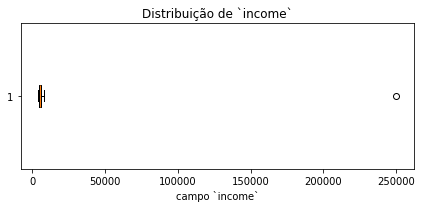

In [168]:
# create a boxplot for income_num
fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot(df["income"].dropna(), vert=False)
ax.set_xlabel("campo `income`")
ax.set_title("Distribuição de `income`")
plt.tight_layout()
plt.show()

# correção para `income`
##  'cap at 99th percentile': tentativa de eliminar outiliers muito discrepantes do resto dos dados
income_cap = df["income"].quantile(0.99)
df["income"] = df["income"].clip(upper=income_cap)
df["income"] = df["income"].fillna(df["income"].median())


In [169]:
#   armazenar o dataset limpo em formato `.csv`
df.to_csv(r'./data/df-cleaned.csv')

# Part B — Core Transformation Tasks


## 10. Create transformed variables

Create the following:

- `signup_month`
- `income_minmax`
- `income_log`
- `segment_encoded`
- `purchases_per_age`
- `income_per_purchase`


In [170]:
# criação das colunas transformadas

# signup_month
df["signup_month"] = df["signup_date"].dt.month

# income_minmax [0,1]
income_min = df["income"].min()
income_max = df["income"].max()
df["income_minmax"] = (df["income"] - income_min) / (income_max - income_min)

# income_log: log1p transformation
df["income_log"] = np.log1p(df["income"])

# segment_encoded: label encoding (Basic=0, Premium=1)
df["segment_encoded"] = df["segment"].map({"Basic": 0, "Premium": 1})

# purchases_per_age: taxa de compras / idade
df["purchases_per_age"] = df["purchases"] / df["age"]

# income_per_purchase: média renda / compras
df["income_per_purchase"] = df["income"] / df["purchases"].replace(0, np.nan)

df[["signup_month", "income_minmax", "income_log",
        "segment_encoded", "purchases_per_age", "income_per_purchase"]].round(3)

,signup_month,income_minmax,income_log,segment_encoded,purchases_per_age,income_per_purchase
0,1.0,0.000,8.343,0,0.120,1400.000
1,2.0,0.004,8.537,0,0.161,1020.000
2,3.0,0.016,8.975,1,0.246,1128.571
3,4.0,0.004,8.537,0,0.069,2550.000
4,NaN,0.008,8.716,1,0.140,1525.000
5,NaN,0.007,8.666,0,0.073,1933.333
6,6.0,0.002,8.456,0,0.035,4700.000
7,7.0,1.000,12.349,1,0.833,7687.733
8,NaN,0.004,8.537,0,0.071,2550.000
9,8.0,0.000,8.367,0,0.107,1433.333


## 11. One-hot encode one categorical variable

Use one-hot encoding for the `city` column.


In [171]:
# one-hot encoding para categorias (`city`)
city_dummies = pd.get_dummies(df["city"], prefix="city", dtype=int)
city_dummies.head()


,city_Curitiba,city_Desconhecido,city_Porto Alegre,city_Rio de Janeiro,city_São Paulo
0,0,0,1,0,0
1,0,0,1,0,0
2,0,0,0,0,1
3,0,0,0,1,0
4,0,0,0,1,0


## 12. Build the final transformed dataset

Create a compact final table ready for future analysis.
Include:
- cleaned core columns
- transformed columns
- one-hot encoded city columns


In [172]:
core_cols = [
    "customer_id", "name", "age", "gender", "city",
    "income", "purchases", "signup_date", "segment"
]
transformed_cols = [
    "signup_month", "income_minmax", "income_log",
    "segment_encoded", "purchases_per_age", "income_per_purchase"
]

df_final = pd.concat(
    [df[core_cols + transformed_cols], city_dummies],
    axis=1
)

print(f"shape: {df_final.shape}")
df_final

shape: (11, 20)


,customer_id,name,age,gender,city,income,purchases,signup_date,segment,signup_month,income_minmax,income_log,segment_encoded,purchases_per_age,income_per_purchase,city_Curitiba,city_Desconhecido,city_Porto Alegre,city_Rio de Janeiro,city_São Paulo
0,101,Ana,25.0,F,Porto Alegre,4200.0,3.0,2024-01-10,Basic,1.0,0.000000,8.343078,0,0.120000,1400.000000,0,0,1,0,0
1,102,Bruno,31.0,M,Porto Alegre,5100.0,5.0,2024-02-15,Basic,2.0,0.003975,8.537192,0,0.161290,1020.000000,0,0,1,0,0
2,103,Carla,28.5,F,São Paulo,7900.0,7.0,2024-03-15,Premium,3.0,0.016340,8.974745,1,0.245614,1128.571429,0,0,0,0,1
3,104,Daniel,29.0,M,Rio de Janeiro,5100.0,2.0,2024-04-01,Basic,4.0,0.003975,8.537192,0,0.068966,2550.000000,0,0,0,1,0
4,105,Eva,28.5,F,Rio de Janeiro,6100.0,4.0,NaT,Premium,NaN,0.008391,8.716208,1,0.140351,1525.000000,0,0,0,1,0
5,106,Desconhecido,41.0,M,Curitiba,5800.0,3.0,NaT,Basic,NaN,0.007066,8.665786,0,0.073171,1933.333333,1,0,0,0,0
6,107,Gustavo,28.5,M,Curitiba,4700.0,1.0,2024-06-20,Basic,6.0,0.002208,8.455531,0,0.035088,4700.000000,1,0,0,0,0
7,108,Helena,36.0,F,Desconhecido,230632.0,30.0,2024-07-01,Premium,7.0,1.000000,12.348583,1,0.833333,7687.733333,0,1,0,0,0
8,109,Igor,28.0,M,Porto Alegre,5100.0,2.0,NaT,Basic,NaN,0.003975,8.537192,0,0.071429,2550.000000,0,0,1,0,0
9,110,Julia,28.0,F,São Paulo,4300.0,3.0,2024-08-10,Basic,8.0,0.000442,8.366603,0,0.107143,1433.333333,0,0,0,0,1


## 13. Optional summary table

Create a small grouped summary by city with:
- average income
- total purchases


In [173]:
# GROUPBY `city`, agregando média de `income`, total de compras e quantidade de consumidores

summary = (
    df_final
    .groupby("city", as_index=True)
    .agg(
        avg_income=("income", "mean"),
        total_purchases=("purchases", "sum"),
        n_customers=("customer_id", "count")
    )
    .round(2)
    .sort_values("avg_income", ascending=False)
)
summary


,avg_income,total_purchases,n_customers
city,,,
Desconhecido,230632.0,30.0,1
Rio de Janeiro,5600.0,6.0,2
São Paulo,5500.0,13.0,3
Curitiba,5250.0,4.0,2
Porto Alegre,4800.0,10.0,3


In [174]:
#   armazenar o dataset transformado em formato `.csv`
df_final.to_csv(r'./data/df-transformed.csv')

# Part C — Competition


## 14. Competition: Best Analysis-Ready Dataset

Your group will submit:

1. one final cleaned + transformed dataset
2. one short markdown explanation
3. one short “quality report”

### Judging criteria
- correctness
- consistency
- clarity
- usefulness for future analysis
- quality of justification

### Tip
A dataset is not “better” just because it has more columns.
It is better if it is **clean, meaningful, and well documented**.


## 15. Team explanation

In the markdown cell below, explain:

- which duplicate handling you used
- how you standardized categories
- how you parsed dates
- how you handled missing values
- what you did with the suspicious income value
- why your final transformed dataset is a good submission


**Write your team explanation here.**


## 16. Quick checklist before submission

Make sure your group has:

- removed exact duplicates
- standardized text categories
- parsed dates into one format
- converted income to numeric
- handled invalid ages
- handled missing values
- created the required transformed columns
- created one-hot encoded city columns
- built a final dataset
- written a short justification


# Final takeaway

A dataset becomes useful through a sequence of careful decisions.

In this lab, the main goal is not to “finish fast,” but to produce a dataset that is:

- correct
- consistent
- clearly documented
- ready for future analysis
